# Summary table
Mika - love today

## 1. Import CSV and find pattern.

In [14]:
def parse_classification_filename(filepath):
    """
    Extract metadata from classification table CSV filenames.

    Handles:
    1. SVM filenames:
       JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01_Test_classification_table.csv

    2. Decision Tree / Random Forest filenames:
       PAT-JYXFE_Test_-_Decision_Tree_classification_table.csv

    Rule:
    Decision Tree and Random Forest are always PCA-based.
    """

    name = Path(filepath).name

    # -------------------------------------------------
    # Pattern 1: SVM
    # -------------------------------------------------
    svm_pattern = re.match(
        r"(?P<patient_id>.+?)_IN-(?P<input_type>FEATURES|PCA)_"
        r"(?P<model>SVM)-SCORING-(?P<scoring>.+?)_"
        r"(?P<date>\d{8})_(?P<version>v\d+)_(?P<dataset>Test|Validation)_classification_table\.csv",
        name
    )

    if svm_pattern:
        info = svm_pattern.groupdict()

        info["model"] = "SVM"
        info["model_group"] = f"{info['input_type']} + SVM"
        info["filename"] = name
        info["filepath"] = str(filepath)
        info["parse_error"] = False

        return info

    # -------------------------------------------------
    # Pattern 2: Decision Tree / Random Forest
    # -------------------------------------------------
    tree_rf_pattern = re.match(
        r"PAT-(?P<patient_id>.+?)_"
        r"(?P<dataset>Test|Validation)_-_"
        r"(?P<model>Decision_Tree|Random_Forest)_classification_table\.csv",
        name
    )

    if tree_rf_pattern:
        info = tree_rf_pattern.groupdict()

        # Fixed rule: DT and RF are always PCA-based
        info["input_type"] = "PCA"
        info["model"] = info["model"].replace("_", " ")
        info["scoring"] = None
        info["date"] = None
        info["version"] = None
        info["model_group"] = f"{info['input_type']} + {info['model']}"
        info["filename"] = name
        info["filepath"] = str(filepath)
        info["parse_error"] = False

        return info

    # -------------------------------------------------
    # If no pattern matched
    # -------------------------------------------------
    return {
        "patient_id": None,
        "input_type": None,
        "model": None,
        "scoring": None,
        "date": None,
        "version": None,
        "dataset": None,
        "model_group": None,
        "filename": name,
        "filepath": str(filepath),
        "parse_error": True
    }

In [15]:
from pathlib import Path
import pandas as pd
import re

# ============================================================
# 1. Define folder containing all classification table CSVs
# ============================================================

classification_tables_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/classification_tables"
)

# Load all CSV paths in that folder
csv_files = sorted(classification_tables_dir.glob("*classification_table.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files found: 24
JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_20260608_v01_Test_classification_table.csv
JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_20260608_v01_Validation_classification_table.csv
JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01_Test_classification_table.csv
JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01_Validation_classification_table.csv
PAT-JYXFE_Test_-_Decision_Tree_classification_table.csv
PAT-JYXFE_Test_-_Random_Forest_classification_table.csv
PAT-JYXFE_Validation_-_Decision_Tree_classification_table.csv
PAT-JYXFE_Validation_-_Random_Forest_classification_table.csv
PAT-RQXZ1_Test_-_Decision_Tree_classification_table.csv
PAT-RQXZ1_Test_-_Random_Forest_classification_table.csv
PAT-RQXZ1_Validation_-_Decision_Tree_classification_table.csv
PAT-RQXZ1_Validation_-_Random_Forest_classification_table.csv
PAT-XB47Y_Test_-_Decision_Tree_classification_table.csv
PAT-XB47Y_Test_-_Random_Forest_classification_table.csv
PAT-XB47Y_Validation_-_Decision_Tree_classification_tabl

In [16]:
metadata_df = pd.DataFrame([
    parse_classification_filename(file)
    for file in csv_files
])

metadata_df

,patient_id,input_type,model,scoring,date,version,dataset,model_group,filename,filepath,parse_error
0,JYXFE,FEATURES,SVM,F1-MACRO,20260608,v01,Test,FEATURES + SVM,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
1,JYXFE,FEATURES,SVM,F1-MACRO,20260608,v01,Validation,FEATURES + SVM,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
2,JYXFE,PCA,SVM,F1-MACRO,20260608,v01,Test,PCA + SVM,JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
3,JYXFE,PCA,SVM,F1-MACRO,20260608,v01,Validation,PCA + SVM,JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
4,JYXFE,PCA,Decision Tree,None,None,None,Test,PCA + Decision Tree,PAT-JYXFE_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
5,JYXFE,PCA,Random Forest,None,None,None,Test,PCA + Random Forest,PAT-JYXFE_Test_-_Random_Forest_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
6,JYXFE,PCA,Decision Tree,None,None,None,Validation,PCA + Decision Tree,PAT-JYXFE_Validation_-_Decision_Tree_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
7,JYXFE,PCA,Random Forest,None,None,None,Validation,PCA + Random Forest,PAT-JYXFE_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
8,RQXZ1,PCA,Decision Tree,None,None,None,Test,PCA + Decision Tree,PAT-RQXZ1_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
9,RQXZ1,PCA,Random Forest,None,None,None,Test,PCA + Random Forest,PAT-RQXZ1_Test_-_Random_Forest_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False


In [17]:
metadata_df.groupby(["dataset", "model_group"]).size()

dataset     model_group        
Test        FEATURES + SVM         3
            PCA + Decision Tree    3
            PCA + Random Forest    3
            PCA + SVM              3
Validation  FEATURES + SVM         3
            PCA + Decision Tree    3
            PCA + Random Forest    3
            PCA + SVM              3
dtype: int64

## 2. Read CSV to build summary df: add data to the metadata_df


In [18]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. Function to extract one metric from one classification CSV
# ============================================================

def extract_classification_metric(
    csv_path,
    metric_row="weighted avg",
    metric_col="f1-score"
):
    """
    Extracts one value from a classification table CSV.

    Example:
    metric_row = "weighted avg"
    metric_col = "f1-score"
    """

    csv_path = Path(csv_path)

    df = pd.read_csv(csv_path)

    # Remove accidental unnamed index columns if present
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Safety check
    if "class_or_metric" not in df.columns:
        raise ValueError(
            f"'class_or_metric' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    if metric_col not in df.columns:
        raise ValueError(
            f"'{metric_col}' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    # Normalize labels to avoid problems with spaces/capitalization
    df["class_or_metric_clean"] = (
        df["class_or_metric"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    metric_row_clean = metric_row.strip().lower()

    metric_match = df[df["class_or_metric_clean"] == metric_row_clean]

    if metric_match.empty:
        raise ValueError(
            f"Metric row '{metric_row}' not found in {csv_path.name}. "
            f"Rows found: {df['class_or_metric'].tolist()}"
        )

    value = metric_match[metric_col].iloc[0]

    return float(value)

In [19]:
# ============================================================
# 2. Build summary dataframe
# ============================================================

def build_summary_df(
    metadata_df,
    metric_row="weighted avg",
    metric_col="f1-score"
):
    """
    Builds one summary dataframe from all classification table CSV files.

    Each CSV becomes one row in the output dataframe.
    """

    summary_rows = []

    for _, row in metadata_df.iterrows():

        # Skip files that were not parsed correctly
        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        metric_value = extract_classification_metric(
            csv_path=csv_path,
            metric_row=metric_row,
            metric_col=metric_col
        )

        summary_rows.append({
            "patient_id": row["patient_id"],
            "dataset": row["dataset"],
            "input_type": row["input_type"],
            "model": row["model"],
            "model_group": row["model_group"],
            "metric_row": metric_row,
            "metric_col": metric_col,
            "metric_value": metric_value,
            "filename": row["filename"],
            "filepath": row["filepath"]
        })

    summary_df = pd.DataFrame(summary_rows)

    return summary_df

In [21]:
summary_df = build_summary_df(
    metadata_df=metadata_df,
    metric_row="weighted avg",
    metric_col="f1-score"
)
summary_df = summary_df.rename(columns={"metric_value": "weighted_f1"})



summary_df

,patient_id,dataset,input_type,model,model_group,metric_row,metric_col,weighted_f1,filename,filepath
0,JYXFE,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.306342,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,JYXFE,Validation,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.519451,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,JYXFE,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.302457,JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,JYXFE,Validation,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.317739,JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,JYXFE,Test,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.302182,PAT-JYXFE_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
5,JYXFE,Test,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.271280,PAT-JYXFE_Test_-_Random_Forest_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
6,JYXFE,Validation,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.499716,PAT-JYXFE_Validation_-_Decision_Tree_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
7,JYXFE,Validation,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.394231,PAT-JYXFE_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
8,RQXZ1,Test,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.513756,PAT-RQXZ1_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
9,RQXZ1,Test,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.501231,PAT-RQXZ1_Test_-_Random_Forest_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [22]:
model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

summary_df["model_group"] = pd.Categorical(
    summary_df["model_group"],
    categories=model_order,
    ordered=True
)

summary_df = summary_df.sort_values(
    by=["dataset", "model_group", "patient_id"]
).reset_index(drop=True)

summary_df

,patient_id,dataset,input_type,model,model_group,metric_row,metric_col,weighted_f1,filename,filepath
0,JYXFE,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.306342,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,RQXZ1,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.433606,RQXZ1_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,XB47Y,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.631620,XB47Y_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,JYXFE,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.302457,JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,RQXZ1,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.471052,RQXZ1_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
5,XB47Y,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.593246,XB47Y_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
6,JYXFE,Test,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.302182,PAT-JYXFE_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
7,RQXZ1,Test,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.513756,PAT-RQXZ1_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
8,XB47Y,Test,PCA,Decision Tree,PCA + Decision Tree,weighted avg,f1-score,0.548810,PAT-XB47Y_Test_-_Decision_Tree_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
9,JYXFE,Test,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.271280,PAT-JYXFE_Test_-_Random_Forest_classification_...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

def plot_summary_metric(
    summary_df,
    dataset_to_plot="Test",
    y_col="weighted_f1",
    baseline=0.5,
    output_path=None,
    show_plot=True
):
    """
    Plot model comparison points for one dataset.
    Each point represents one patient.

    Also adds:
    - Horizontal dashed baseline
    - Mean per model category
    - Median per model category
    """

    df_plot = summary_df.copy()

    # -------------------------------------------------
    # Filter dataset
    # -------------------------------------------------
    if dataset_to_plot is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_to_plot].copy()

    # -------------------------------------------------
    # Keep only model groups present in the dataframe
    # -------------------------------------------------
    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    # -------------------------------------------------
    # Calculate mean and median per category
    # -------------------------------------------------
    stats_df = (
        df_plot
        .groupby("model_group", observed=True)[y_col]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(stats_df)

    # -------------------------------------------------
    # Plot patient-level points
    # -------------------------------------------------
    plt.figure(figsize=(11, 5.5))

    ax = sns.stripplot(
        data=df_plot,
        x="model_group",
        y=y_col,
        order=current_order,
        hue="patient_id",
        jitter=0.18,
        size=8,
        alpha=0.85
    )

    # -------------------------------------------------
    # Horizontal baseline
    # -------------------------------------------------
    ax.axhline(
        y=baseline,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7,
        label=f"Baseline = {baseline}"
    )

    # -------------------------------------------------
    # Add mean and median per category
    # -------------------------------------------------
    for i, model_group in enumerate(current_order):

        row = stats_df[stats_df["model_group"] == model_group]

        if row.empty:
            continue

        mean_value = row["mean"].iloc[0]
        median_value = row["median"].iloc[0]

        # Mean: solid short horizontal line
        ax.hlines(
            y=mean_value,
            xmin=i - 0.25,
            xmax=i + 0.25,
            colors="red",
            linestyles="-",
            linewidth=2.5,
            label="Mean" if i == 0 else None
        )

        # Median: dashed short horizontal line
        ax.hlines(
            y=median_value,
            xmin=i - 0.25,
            xmax=i + 0.25,
            colors="blue",
            linestyles="--",
            linewidth=2.5,
            label="Median" if i == 0 else None
        )

        # Text annotation
        ax.text(
            x=i + 0.28,
            y=mean_value,
            s=f"mean={mean_value:.2f}",
            va="center",
            fontsize=9,
            color="red"
        )

        ax.text(
            x=i + 0.28,
            y=median_value,
            s=f"med={median_value:.2f}",
            va="center",
            fontsize=9,
            color="blue"
        )

    # -------------------------------------------------
    # Labels and formatting
    # -------------------------------------------------
    ax.set_title(f"{dataset_to_plot} performance comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Weighted F1-score")
    ax.set_ylim(0, 1)

    plt.xticks(rotation=25, ha="right")

    plt.legend(
        title="Patient / summary",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

           model_group      mean    median  count
0       FEATURES + SVM  0.457189  0.433606      3
1            PCA + SVM  0.455585  0.471052      3
2  PCA + Decision Tree  0.454916  0.513756      3
3  PCA + Random Forest  0.471178  0.501231      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/Test_weighted_f1_summary_plot.png


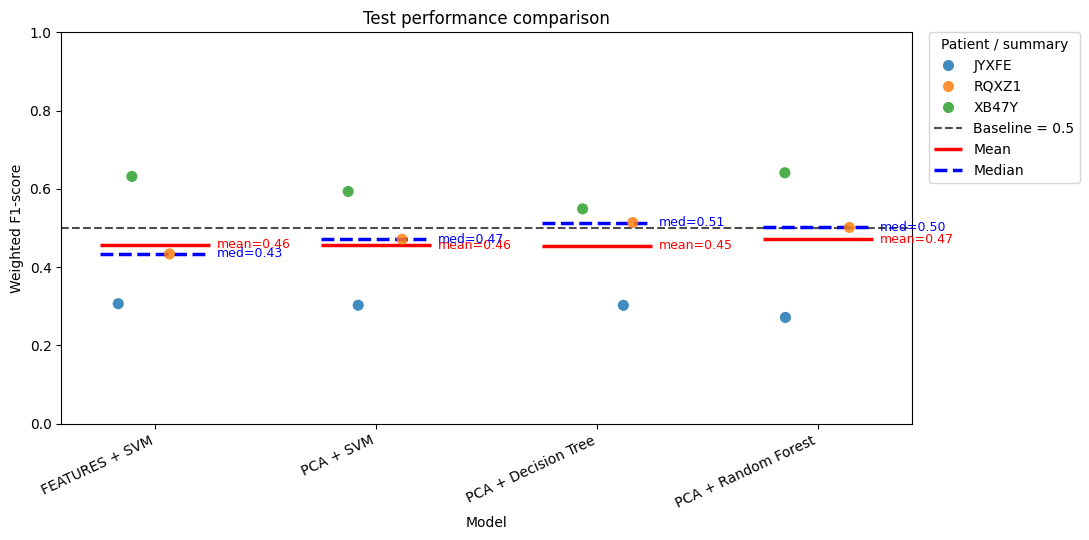

In [41]:
plot_summary_metric(
    summary_df=summary_df,
    dataset_to_plot="Test",
    y_col="weighted_f1",
    baseline=0.5,
    output_path="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/Test_weighted_f1_summary_plot.png",
    show_plot=True
)

## 3. Plot 3 metrics at the same time: 3 plots (avg, seizure and preictal)

In [30]:
def build_multi_metric_summary_df(metadata_df):
    """
    Builds a long-format summary dataframe with:
    1. weighted avg f1-score
    2. preictal f1-score
    3. seizure f1-score
    """

    metrics_to_extract = [
        {
            "metric_name": "Weighted F1",
            "metric_row": "weighted avg",
            "metric_col": "f1-score"
        },
        {
            "metric_name": "Preictal F1",
            "metric_row": "preictal",
            "metric_col": "f1-score"
        },
        {
            "metric_name": "Seizure F1",
            "metric_row": "seizure",
            "metric_col": "f1-score"
        },
    ]

    summary_rows = []

    for _, row in metadata_df.iterrows():

        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        for metric in metrics_to_extract:

            metric_value = extract_classification_metric(
                csv_path=csv_path,
                metric_row=metric["metric_row"],
                metric_col=metric["metric_col"]
            )

            summary_rows.append({
                "patient_id": row["patient_id"],
                "dataset": row["dataset"],
                "input_type": row["input_type"],
                "model": row["model"],
                "model_group": row["model_group"],
                "metric_name": metric["metric_name"],
                "metric_row": metric["metric_row"],
                "metric_col": metric["metric_col"],
                "metric_value": metric_value,
                "filename": row["filename"],
                "filepath": row["filepath"]
            })

    summary_df_long = pd.DataFrame(summary_rows)

    return summary_df_long

In [31]:
summary_df_long = build_multi_metric_summary_df(metadata_df)

summary_df_long.head()

,patient_id,dataset,input_type,model,model_group,metric_name,metric_row,metric_col,metric_value,filename,filepath
0,JYXFE,Test,FEATURES,SVM,FEATURES + SVM,Weighted F1,weighted avg,f1-score,0.306342,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,JYXFE,Test,FEATURES,SVM,FEATURES + SVM,Preictal F1,preictal,f1-score,0.344828,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,JYXFE,Test,FEATURES,SVM,FEATURES + SVM,Seizure F1,seizure,f1-score,0.269231,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,JYXFE,Validation,FEATURES,SVM,FEATURES + SVM,Weighted F1,weighted avg,f1-score,0.519451,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,JYXFE,Validation,FEATURES,SVM,FEATURES + SVM,Preictal F1,preictal,f1-score,0.473684,JYXFE_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D

model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

def plot_metric_from_summary_long(
    summary_df_long,
    metric_name,
    dataset_to_plot="Test",
    baseline=0.5,
    output_path=None,
    show_plot=True,
    add_stats_text=True
):
    """
    Plot one metric from summary_df_long.

    Each point represents one patient.

    Uses:
    - Same color for all patients
    - Different marker/symbol per patient
    - Fixed horizontal offset per patient to avoid overlap
    - Optional baseline at 0.5
    - Mean/median/n text at the top of each category
    """

    df_plot = summary_df_long.copy()

    df_plot = df_plot[
        (df_plot["dataset"] == dataset_to_plot) &
        (df_plot["metric_name"] == metric_name)
    ].copy()

    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    # -------------------------------------------------
    # Calculate mean and median per category
    # -------------------------------------------------
    stats_df = (
        df_plot
        .groupby("model_group", observed=True)["metric_value"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(f"\n{dataset_to_plot} - {metric_name}")
    print(stats_df)

    # -------------------------------------------------
    # Patient marker and offset mapping
    # -------------------------------------------------
    patient_order = sorted(df_plot["patient_id"].unique())

    markers = ["o", "s", "^", "D", "v", "P", "*", "<", ">"]

    if len(patient_order) > len(markers):
        raise ValueError(
            f"Not enough marker types for {len(patient_order)} patients. "
            f"Add more markers to the markers list."
        )

    patient_to_marker = {
        patient: markers[i]
        for i, patient in enumerate(patient_order)
    }

    # Fixed offsets instead of random jitter
    if len(patient_order) == 1:
        offsets = [0]
    else:
        offsets = np.linspace(-0.16, 0.16, len(patient_order))

    patient_to_offset = {
        patient: offsets[i]
        for i, patient in enumerate(patient_order)
    }

    model_to_x = {
        model: i
        for i, model in enumerate(current_order)
    }

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for _, row in df_plot.iterrows():

        model_group = row["model_group"]
        patient_id = row["patient_id"]
        y_value = row["metric_value"]

        x_value = model_to_x[model_group] + patient_to_offset[patient_id]

        ax.scatter(
            x_value,
            y_value,
            marker=patient_to_marker[patient_id],
            s=85,
            facecolors="white",
            edgecolors="black",
            linewidths=1.4,
            alpha=0.95,
            zorder=3
        )

    # -------------------------------------------------
    # Optional horizontal baseline
    # -------------------------------------------------
    if baseline is not None:
        ax.axhline(
            y=baseline,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.7,
            label=f"Baseline = {baseline}",
            zorder=1
        )

    # -------------------------------------------------
    # Add mean and median as text inside plot
    # -------------------------------------------------
    if add_stats_text:
        for i, model_group in enumerate(current_order):

            row = stats_df[stats_df["model_group"] == model_group]

            if row.empty:
                continue

            mean_value = row["mean"].iloc[0]
            median_value = row["median"].iloc[0]
            count_value = int(row["count"].iloc[0])

            stats_text = (
                f"mean={mean_value:.2f}\n"
                f"med={median_value:.2f}\n"
                f"n={count_value}"
            )

            ax.text(
                x=i,
                y=0.98,
                s=stats_text,
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.8
                ),
                zorder=4
            )

    # -------------------------------------------------
    # Axis formatting
    # -------------------------------------------------
    ax.set_title(f"{dataset_to_plot} - {metric_name}")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1)

    ax.set_xticks(range(len(current_order)))
    ax.set_xticklabels(current_order, rotation=25, ha="right")

    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # -------------------------------------------------
    # Custom legend for patient symbols
    # -------------------------------------------------
    patient_handles = [
        Line2D(
            [0],
            [0],
            marker=patient_to_marker[patient],
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.4,
            linestyle="None",
            markersize=8,
            label=patient
        )
        for patient in patient_order
    ]

    legend_handles = patient_handles

    if baseline is not None:
        baseline_handle = Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Baseline = {baseline}"
        )
        legend_handles.append(baseline_handle)

    ax.legend(
        handles=legend_handles,
        title="Patient",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


Test - Weighted F1
           model_group      mean    median  count
0       FEATURES + SVM  0.457189  0.433606      3
1            PCA + SVM  0.455585  0.471052      3
2  PCA + Decision Tree  0.454916  0.513756      3
3  PCA + Random Forest  0.471178  0.501231      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_weighted_f1_summary_plot.png


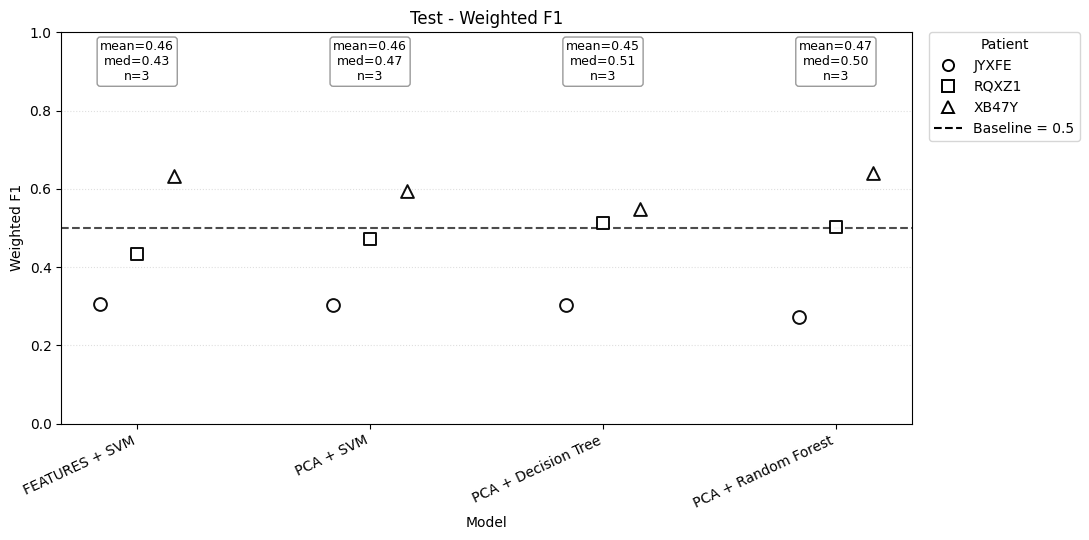


Test - Preictal F1
           model_group      mean    median  count
0       FEATURES + SVM  0.557766  0.645545      3
1            PCA + SVM  0.461507  0.654545      3
2  PCA + Decision Tree  0.458498  0.476190      3
3  PCA + Random Forest  0.494543  0.594966      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_preictal_f1_summary_plot.png


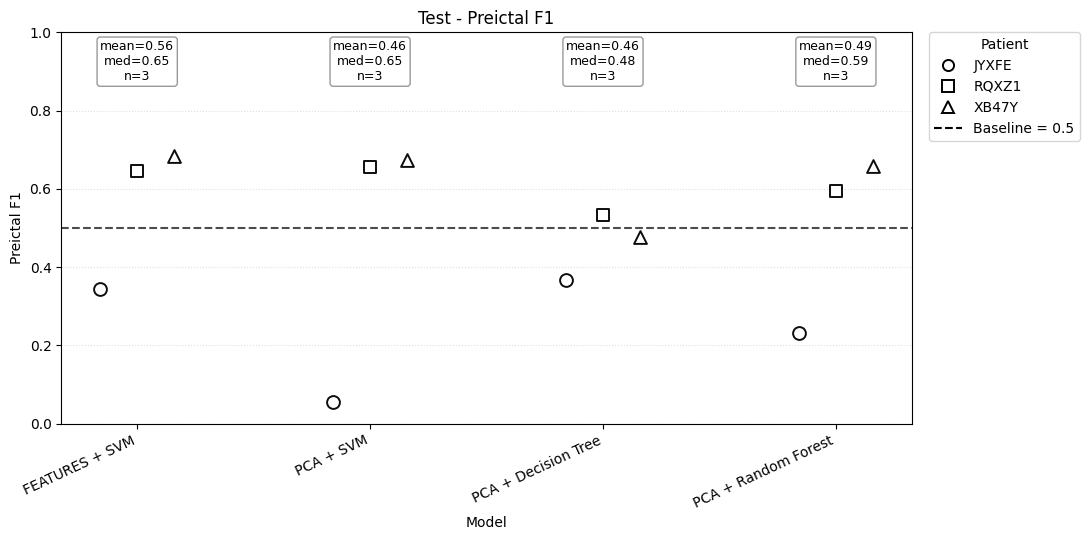


Test - Seizure F1
           model_group      mean    median  count
0       FEATURES + SVM  0.364913  0.269231      3
1            PCA + SVM  0.456723  0.533333      3
2  PCA + Decision Tree  0.446061  0.495775      3
3  PCA + Random Forest  0.450292  0.411960      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_seizure_f1_summary_plot.png


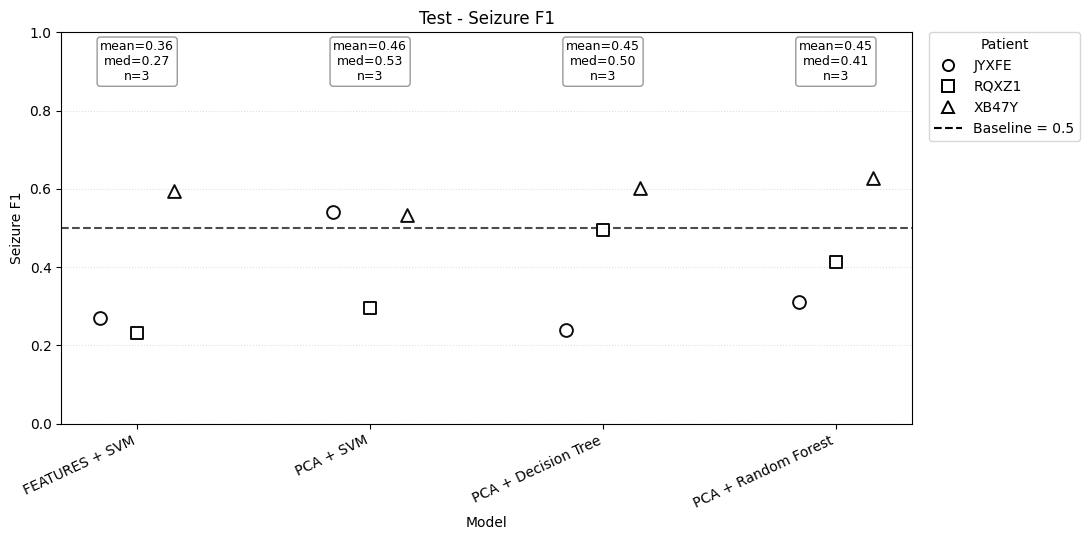

In [38]:
# TEST!!!
output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots"
)

metrics_to_plot = [
    "Weighted F1",
    "Preictal F1",
    "Seizure F1",
]

for metric_name in metrics_to_plot:
    safe_metric_name = metric_name.lower().replace(" ", "_")

    plot_metric_from_summary_long(
        summary_df_long=summary_df_long,
        metric_name=metric_name,
        dataset_to_plot="Test",
        baseline=0.5,
        output_path=output_dir / f"Test_{safe_metric_name}_summary_plot.png",
        show_plot=True
    )


Validation - Weighted F1
           model_group      mean    median  count
0       FEATURES + SVM  0.562624  0.519451      3
1            PCA + SVM  0.494555  0.494577      3
2  PCA + Decision Tree  0.571518  0.499716      3
3  PCA + Random Forest  0.515030  0.502674      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_weighted_f1_summary_plot.png


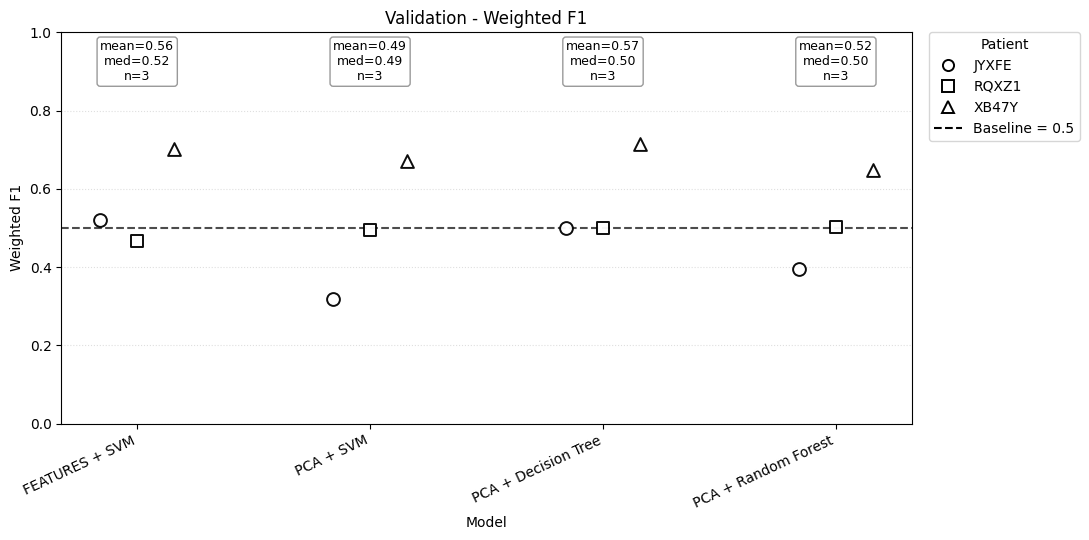


Validation - Preictal F1
           model_group      mean    median  count
0       FEATURES + SVM  0.581424  0.564706      3
1            PCA + SVM  0.435459  0.555831      3
2  PCA + Decision Tree  0.552033  0.487805      3
3  PCA + Random Forest  0.446235  0.506887      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_preictal_f1_summary_plot.png


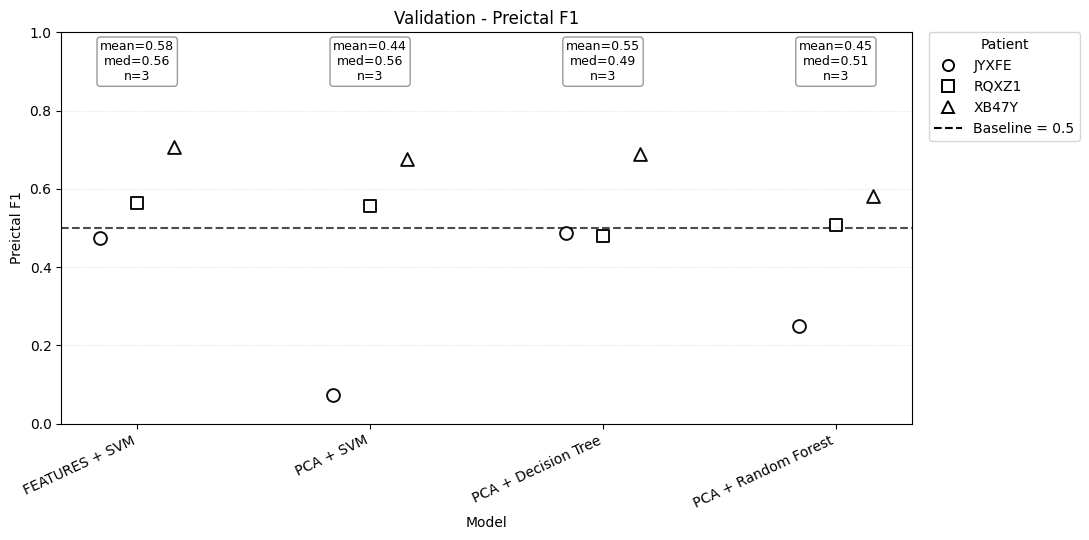


Validation - Seizure F1
           model_group      mean    median  count
0       FEATURES + SVM  0.545023  0.565217      3
1            PCA + SVM  0.554467  0.561404      3
2  PCA + Decision Tree  0.590024  0.518717      3
3  PCA + Random Forest  0.581974  0.538462      3
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_seizure_f1_summary_plot.png


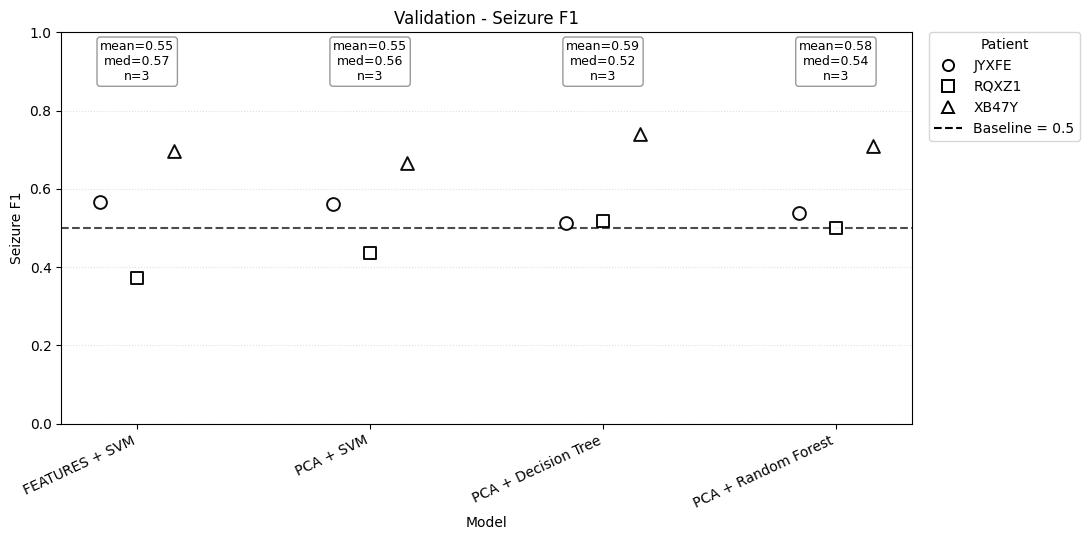

In [39]:
# VALIDATION!!
for metric_name in metrics_to_plot:
    safe_metric_name = metric_name.lower().replace(" ", "_")

    plot_metric_from_summary_long(
        summary_df_long=summary_df_long,
        metric_name=metric_name,
        dataset_to_plot="Validation",
        baseline=0.5,
        output_path=output_dir / f"Validation_{safe_metric_name}_summary_plot.png",
        show_plot=True,
        add_stats_text=True
    )

## 4. Accuracy

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D

model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

def plot_accuracy_by_dataset(
    summary_accuracy_df,
    dataset_to_plot="Test",
    baseline=0.5,
    output_path=None,
    show_plot=True,
    add_stats_text=True
):
    """
    Plot accuracy for one dataset: Test or Validation.

    Each point represents one patient.
    Different symbols represent different patients.
    """

    df_plot = summary_accuracy_df.copy()

    df_plot = df_plot[
        df_plot["dataset"] == dataset_to_plot
    ].copy()

    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    # -------------------------------------------------
    # Calculate mean and median per model category
    # -------------------------------------------------
    stats_df = (
        df_plot
        .groupby("model_group", observed=True)["accuracy"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(f"\nAccuracy - {dataset_to_plot}")
    print(stats_df)

    # -------------------------------------------------
    # Patient marker mapping
    # -------------------------------------------------
    patient_order = sorted(df_plot["patient_id"].unique())

    markers = ["o", "s", "^", "D", "v", "P", "*", "<", ">"]

    if len(patient_order) > len(markers):
        raise ValueError(
            f"Not enough marker types for {len(patient_order)} patients. "
            f"Add more markers to the markers list."
        )

    patient_to_marker = {
        patient: markers[i]
        for i, patient in enumerate(patient_order)
    }

    # Fixed horizontal offsets to avoid overlap
    if len(patient_order) == 1:
        offsets = [0]
    else:
        offsets = np.linspace(-0.16, 0.16, len(patient_order))

    patient_to_offset = {
        patient: offsets[i]
        for i, patient in enumerate(patient_order)
    }

    model_to_x = {
        model: i
        for i, model in enumerate(current_order)
    }

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for _, row in df_plot.iterrows():

        model_group = row["model_group"]
        patient_id = row["patient_id"]
        y_value = row["accuracy"]

        x_value = model_to_x[model_group] + patient_to_offset[patient_id]

        ax.scatter(
            x_value,
            y_value,
            marker=patient_to_marker[patient_id],
            s=85,
            facecolors="white",
            edgecolors="black",
            linewidths=1.4,
            alpha=0.95,
            zorder=3
        )

    # -------------------------------------------------
    # Baseline
    # -------------------------------------------------
    if baseline is not None:
        ax.axhline(
            y=baseline,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.7,
            zorder=1
        )

    # -------------------------------------------------
    # Add mean and median text inside plot
    # -------------------------------------------------
    if add_stats_text:
        for i, model_group in enumerate(current_order):

            row = stats_df[stats_df["model_group"] == model_group]

            if row.empty:
                continue

            mean_value = row["mean"].iloc[0]
            median_value = row["median"].iloc[0]
            count_value = int(row["count"].iloc[0])

            stats_text = (
                f"mean={mean_value:.2f}\n"
                f"med={median_value:.2f}\n"
                f"n={count_value}"
            )

            ax.text(
                x=i,
                y=0.98,
                s=stats_text,
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.8
                ),
                zorder=4
            )

    # -------------------------------------------------
    # Formatting
    # -------------------------------------------------
    ax.set_title(f"Accuracy - {dataset_to_plot}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)

    ax.set_xticks(range(len(current_order)))
    ax.set_xticklabels(current_order, rotation=25, ha="right")

    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # -------------------------------------------------
    # Legend
    # -------------------------------------------------
    patient_handles = [
        Line2D(
            [0],
            [0],
            marker=patient_to_marker[patient],
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.4,
            linestyle="None",
            markersize=8,
            label=patient
        )
        for patient in patient_order
    ]

    legend_handles = patient_handles

    if baseline is not None:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="--",
                linewidth=1.5,
                label=f"Baseline = {baseline}"
            )
        )

    ax.legend(
        handles=legend_handles,
        title="Patient",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

In [43]:
output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots"
)

for dataset_name in ["Test", "Validation"]:

    plot_accuracy_by_dataset(
        summary_accuracy_df=summary_accuracy_df,
        dataset_to_plot=dataset_name,
        baseline=0.5,
        output_path=output_dir / f"Accuracy_{dataset_name}_summary_plot.png",
        show_plot=True,
        add_stats_text=True
    )

NameError: name 'summary_accuracy_df' is not defined